In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/annotations.xml
/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/receipts.csv
/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/boxes/11.png
/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/boxes/4.png
/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/boxes/9.png
/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/boxes/14.png
/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/boxes/1.png
/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/boxes/2.png
/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/boxes/10.png
/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/boxes/18.png
/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/boxes/12.png
/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/boxes/7.png
/kaggle/input/datasets/trainingdatapro/ocr

In [2]:
# Install EasyOCR and other necessary packages
!pip install easyocr -q

# Verify Tesseract (already pre-installed on Kaggle)
!tesseract --version

tesseract 4.1.1
 leptonica-1.82.0
  libgif 5.1.9 : libjpeg 8d (libjpeg-turbo 2.1.1) : libpng 1.6.37 : libtiff 4.3.0 : zlib 1.2.11 : libwebp 1.2.2 : libopenjp2 2.4.0
 Found AVX2
 Found AVX
 Found FMA
 Found SSE
 Found libarchive 3.6.0 zlib/1.2.11 liblzma/5.2.5 bz2lib/1.0.8 liblz4/1.9.3 libzstd/1.4.8


In [3]:
import os
import cv2
import pytesseract
import easyocr
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import re

# Set paths
base_path = '/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection'
images_path = os.path.join(base_path, 'images')

# Get all images and pick the third one (index 2)
image_files = [f for f in os.listdir(images_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
image_files.sort()  # Ensure consistent order

third_image_name = image_files[16]  # Third image
third_image_path = os.path.join(images_path, third_image_name)

print(f"Third image filename: {third_image_name}")
print(f"Full path: {third_image_path}")

Third image filename: 6.JPG
Full path: /kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/images/6.JPG


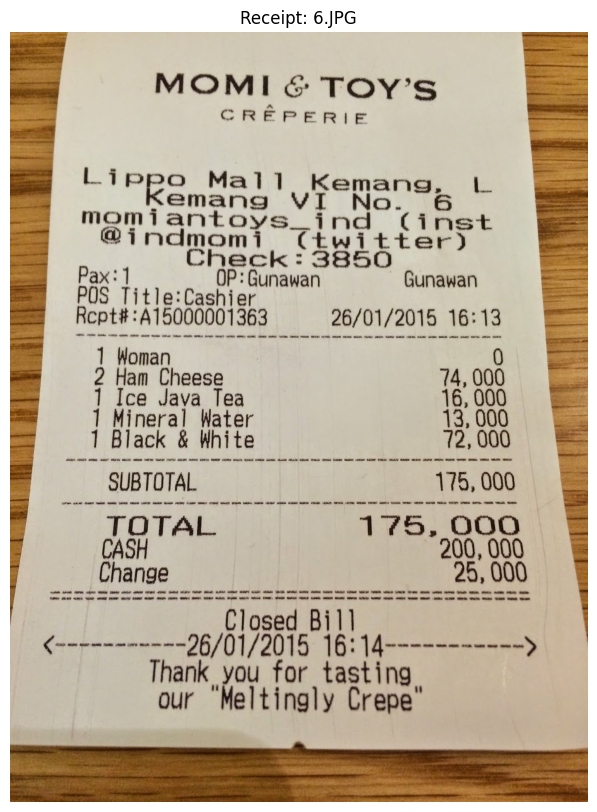

In [4]:
# Load and display
img_pil = Image.open(third_image_path)
plt.figure(figsize=(8, 10))
plt.imshow(img_pil)
plt.title(f'Receipt: {third_image_name}')
plt.axis('off')
plt.show()

In [5]:
text = pytesseract.image_to_string(img_pil)
print("=== TESSERACT OCR OUTPUT ===")
print(text)

=== TESSERACT OCR OUTPUT ===
MOMI & TOY’S

CREPERIE

Lippo Mall K
Kenana vi Noo ~

oO
momiantoys_ind Cinst
@indmomi Ctwitter)
Check: 3850
Pax: 1] OP: Gunawan Gunawan
POS Title:Cashier
Rept#: 415000001363 26/01/2015 16:13
1 Woman 0
2 Ham Cheese 74, 000
1 Ice Java Tea 16, 000
1 Mineral Water 13, 000
1 Black & White 72, 000
SUBTOTAL 175, 000
TOTAL 175, 000
CASH 200, 000
Change 2

2a ae ne Ne a La SS A Rc mee Se

d Bil
ween nnn nn 96/81 9565 16. 14----------->
Thank you for tasting
our “Meltingly Crepe"

 



In [6]:
data = pytesseract.image_to_data(img_pil, output_type='dict')
df = pd.DataFrame(data)
df = df[df['text'].str.strip() != '']
df = df[df['conf'] != -1]

print("=== CONFIDENCE SCORES (first 20) ===")
print(df[['text', 'conf']].head(20))
print(f"\nAverage confidence: {df['conf'].mean():.1f}%")
print(f"Words detected: {len(df)}")

=== CONFIDENCE SCORES (first 20) ===
              text  conf
4             MOMI    60
5                &    60
6            TOY’S    88
10        CREPERIE    90
14           Lippo    70
15            Mall    89
16               K    87
18          Kenana     0
19              vi    77
20             Noo     0
21               ~     0
25              oO    38
27  momiantoys_ind    88
28           Cinst    89
30        @indmomi    75
31       Ctwitter)    84
33          Check:    64
34            3850    64
36            Pax:    38
37              1]    38

Average confidence: 70.7%
Words detected: 92


In [7]:
!pip install easyocr -q
reader = easyocr.Reader(['en'])
print("EasyOCR initialized!")

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


EasyOCR initialized!


In [8]:
import os
import cv2
import pytesseract
import easyocr
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import re

# Paths
base_path = '/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection'
images_path = os.path.join(base_path, 'images')

# Get all images sorted
image_files = sorted([f for f in os.listdir(images_path) if f.lower().endswith(('.jpg','.jpeg','.png'))])

# Use index 16 (the 17th image) – change if you want a different one
target_index = 16
target_image_name = image_files[target_index]
target_image_path = os.path.join(images_path, target_image_name)

print(f"Using image: {target_image_name}")
print(f"Full path: {target_image_path}")

Using image: 6.JPG
Full path: /kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/images/6.JPG


In [9]:
# This cell assumes target_image_path is defined
result = reader.readtext(target_image_path)
print("=== EasyOCR RESULTS ===")
for detection in result[:20]:
    bbox, text, confidence = detection
    print(f"Text: {text:30s} | Confidence: {confidence:.2f}")

full_easy_text = ' '.join([det[1] for det in result])
print("\n=== FULL EXTRACTED TEXT ===")
print(full_easy_text[:500])

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


=== EasyOCR RESULTS ===
Text: MOMI                           | Confidence: 0.94
Text: & Toy's                        | Confidence: 0.55
Text: CREPERTE                       | Confidence: 0.41
Text: Lippema3g                      | Confidence: 0.64
Text: Mal 1                          | Confidence: 0.39
Text: L                              | Confidence: 1.00
Text: VI                             | Confidence: 0.93
Text: No.                            | Confidence: 0.38
Text: momiantoys_                    | Confidence: 0.76
Text: ind                            | Confidence: 0.99
Text: {inst                          | Confidence: 0.42
Text: @indmomi                       | Confidence: 0.83
Text: Tiwitter)                      | Confidence: 0.53
Text: Check: 3850                    | Confidence: 0.68
Text: Pax: 1                         | Confidence: 0.57
Text: OP : Gunawan                   | Confidence: 0.48
Text: Gunawan                        | Confidence: 1.00
Text: POS Title: Cashier

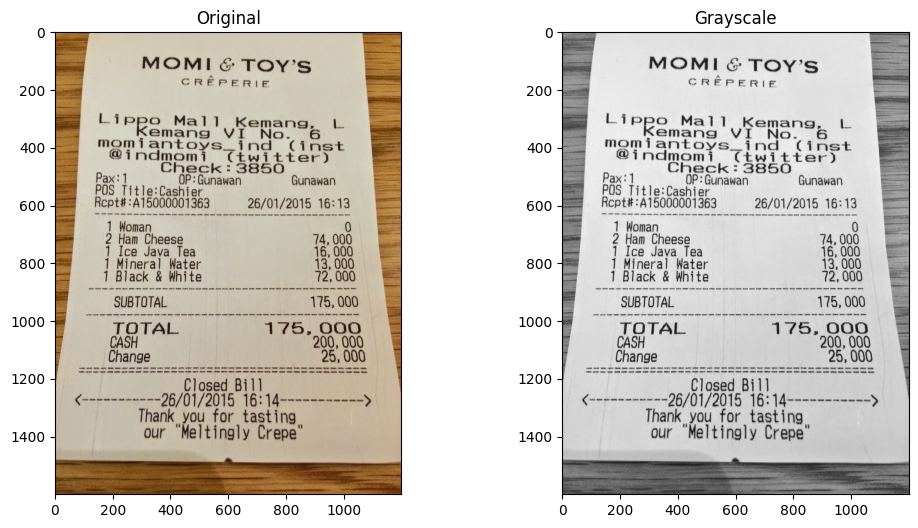

In [10]:
img_cv = cv2.imread(target_image_path)
gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)

fig, axes = plt.subplots(1,2, figsize=(12,6))
axes[0].imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[1].imshow(gray, cmap='gray')
axes[1].set_title('Grayscale')
plt.show()

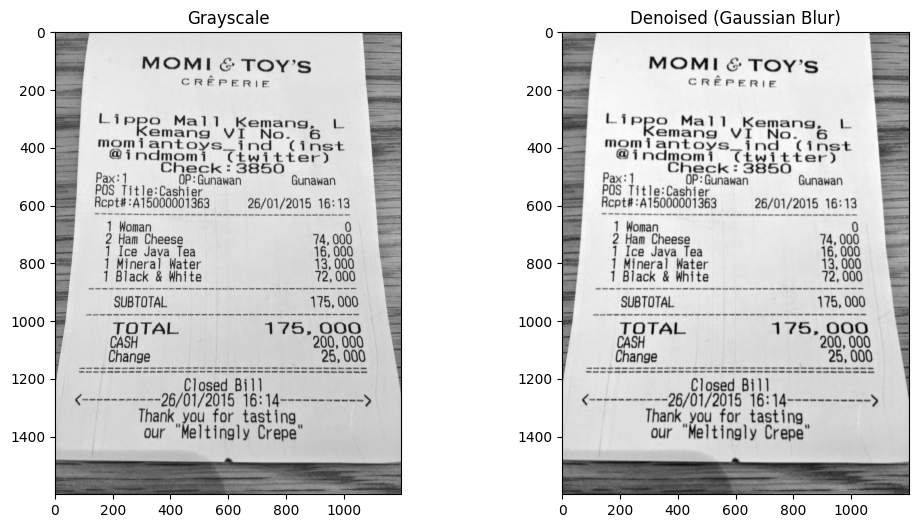

In [11]:
denoised = cv2.GaussianBlur(gray, (5,5), 0)

fig, axes = plt.subplots(1,2, figsize=(12,6))
axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Grayscale')
axes[1].imshow(denoised, cmap='gray')
axes[1].set_title('Denoised (Gaussian Blur)')
plt.show()

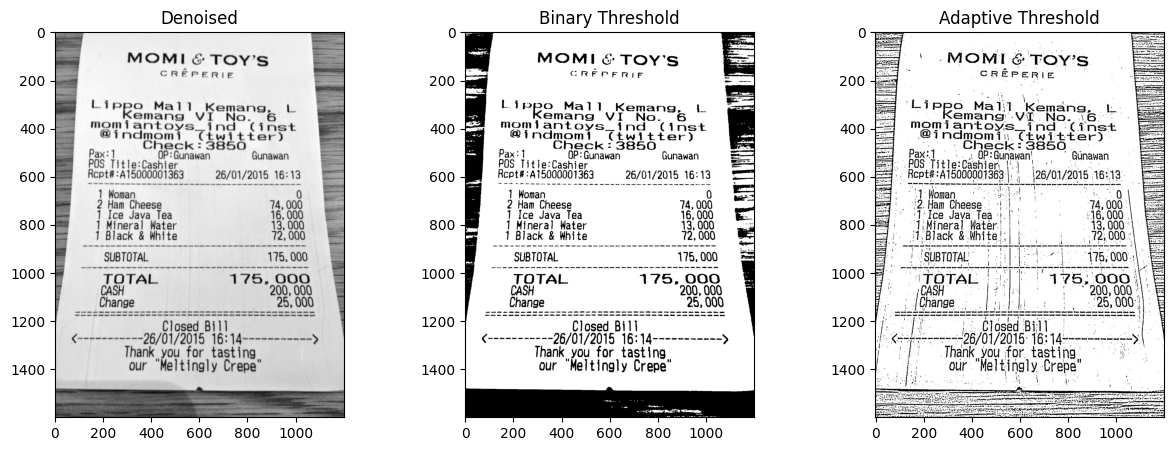

In [12]:
_, binary = cv2.threshold(denoised, 127, 255, cv2.THRESH_BINARY)
adaptive = cv2.adaptiveThreshold(denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                 cv2.THRESH_BINARY, 11, 2)

fig, axes = plt.subplots(1,3, figsize=(15,5))
axes[0].imshow(denoised, cmap='gray')
axes[0].set_title('Denoised')
axes[1].imshow(binary, cmap='gray')
axes[1].set_title('Binary Threshold')
axes[2].imshow(adaptive, cmap='gray')
axes[2].set_title('Adaptive Threshold')
plt.show()

processing

In [13]:
# Original (no preprocessing)
text_before = pytesseract.image_to_string(img_pil)

# Preprocessed (adaptive threshold)
text_after = pytesseract.image_to_string(Image.fromarray(adaptive))

print("=== BEFORE PREPROCESSING ===")
print(text_before)
print(f"Character count: {len(text_before)}")

print("\n=== AFTER PREPROCESSING ===")
print(text_after)
print(f"Character count: {len(text_after)}")

improvement = len(text_after) - len(text_before)
if len(text_before) > 0:
    percent = (improvement / len(text_before)) * 100
    print(f"\n📈 Improvement: +{improvement} characters ({percent:.1f}% increase)")
else:
    print(f"\n📈 Improvement: +{improvement} characters (original had 0)")

=== BEFORE PREPROCESSING ===
MOMI & TOY’S

CREPERIE

Lippo Mall K
Kenana vi Noo ~

oO
momiantoys_ind Cinst
@indmomi Ctwitter)
Check: 3850
Pax: 1] OP: Gunawan Gunawan
POS Title:Cashier
Rept#: 415000001363 26/01/2015 16:13
1 Woman 0
2 Ham Cheese 74, 000
1 Ice Java Tea 16, 000
1 Mineral Water 13, 000
1 Black & White 72, 000
SUBTOTAL 175, 000
TOTAL 175, 000
CASH 200, 000
Change 2

2a ae ne Ne a La SS A Rc mee Se

d Bil
ween nnn nn 96/81 9565 16. 14----------->
Thank you for tasting
our “Meltingly Crepe"

 

Character count: 480

=== AFTER PREPROCESSING ===
      
      

| \ .MOMIéTOY’s

CREPERIE

Lippe Maia vigemaina, L.

emang: -V'T . No. \60:

memiantoys ind -Cinst
oF ndmomi i, Chwi tter)

Meck:

~ Pax: oY OP: Gu nawan'  Gunawan

‘POS Titlese ashier yt 7

» Reet Aiboo000 S63 y yon 16: 13.

      
               
       
  
       
   
 
 

Black &. ‘Hhite

re ‘Han Cheese .| ne 74, 000 :
‘T'Ice Java Teas. |: 16, 000
“1Mineral Water.| | | 13, 000°
i ei sf 00!

“Fora :
[Change nll a . 98,

 OCR Comparison

In [14]:
def compare_ocr_methods(image_path):
    """Compare Tesseract (with preprocessing) vs EasyOCR"""
    # Load and preprocess
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    denoised = cv2.GaussianBlur(gray, (5,5), 0)
    thresh = cv2.adaptiveThreshold(denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY, 11, 2)
    # Tesseract on preprocessed
    tess_text = pytesseract.image_to_string(Image.fromarray(thresh))
    # EasyOCR
    easy_result = reader.readtext(image_path)
    easy_text = ' '.join([r[1] for r in easy_result])
    return tess_text, easy_text

# Test on our target image
tess_res, easy_res = compare_ocr_methods(target_image_path)
print(f"Tesseract (preprocessed) output length: {len(tess_res)} characters")
print(f"EasyOCR output length: {len(easy_res)} characters")
print("\nTesseract sample:\n", tess_res[:300])
print("\nEasyOCR sample:\n", easy_res[:300])

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Tesseract (preprocessed) output length: 720 characters
EasyOCR output length: 423 characters

Tesseract sample:
       
      

| \ .MOMIéTOY’s

CREPERIE

Lippe Maia vigemaina, L.

emang: -V'T . No. \60:

memiantoys ind -Cinst
oF ndmomi i, Chwi tter)

Meck:

~ Pax: oY OP: Gu nawan'  Gunawan

‘POS Titlese ashier yt 7

» Reet Aiboo000 S63 y yon 16: 13.

      
               
       
  
       
   
 
 

Black &.

EasyOCR sample:
 MOMI & Toy's CREPERTE Lippema3g Mal 1 L VI No. momiantoys_ ind {inst @indmomi Tiwitter) Check: 3850 Pax: 1 OP : Gunawan Gunawan POS Title: Cashier Rcpt#:A15000001363 26/01/2015 16:13 1 Woman 2 Ham Cheese 74,000 Ice Java Tea 16, 000 Minera] Water 13,000 Black & White 72, 000 SUBTOTAL 175,000 TOTAL 17


Receipt Parser Output

In [15]:
def parse_receipt(text):
    info = {'merchant': None, 'date': None, 'total': None}
    
    # Merchant: first non-empty line
    lines = [l.strip() for l in text.split('\n') if l.strip()]
    if lines:
        info['merchant'] = lines[0][:50]
    
    # Date patterns
    date_patterns = [r'\d{1,2}[/-]\d{1,2}[/-]\d{2,4}',
                     r'\d{4}[/-]\d{1,2}[/-]\d{1,2}']
    for pattern in date_patterns:
        match = re.search(pattern, text)
        if match:
            info['date'] = match.group()
            break
    
    # Total patterns
    total_patterns = [r'TOTAL[:\s]*\$?(\d+\.\d{2})',
                      r'Total[:\s]*\$?(\d+\.\d{2})',
                      r'AMOUNT[:\s]*\$?(\d+\.\d{2})',
                      r'Amount[:\s]*\$?(\d+\.\d{2})',
                      r'\$(\d+\.\d{2})\s*$']
    for pattern in total_patterns:
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            info['total'] = f"${match.group(1)}"
            break
    return info

# Parse the preprocessed text
parsed = parse_receipt(text_after)
print("=== PARSED RECEIPT DATA ===")
print(f"Merchant: {parsed['merchant']}")
print(f"Date: {parsed['date']}")
print(f"Total: {parsed['total']}")

=== PARSED RECEIPT DATA ===
Merchant: | \ .MOMIéTOY’s
Date: None
Total: None


Receipt OCR Results

In [16]:
def process_multiple_receipts(image_list, image_folder, num=5):
    results = []
    for i, fname in enumerate(image_list[:num]):
        fpath = os.path.join(image_folder, fname)
        # Preprocess
        img = cv2.imread(fpath)
        if img is None:
            continue
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        denoised = cv2.GaussianBlur(gray, (5,5), 0)
        thresh = cv2.adaptiveThreshold(denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                       cv2.THRESH_BINARY, 11, 2)
        tess_text = pytesseract.image_to_string(Image.fromarray(thresh))
        easy_res = reader.readtext(fpath)
        easy_text = ' '.join([r[1] for r in easy_res])
        parsed_info = parse_receipt(tess_text)
        results.append({
            'filename': fname,
            'tesseract_chars': len(tess_text),
            'easyocr_chars': len(easy_text),
            'merchant': parsed_info['merchant'],
            'date': parsed_info['date'],
            'total': parsed_info['total']
        })
        print(f"✅ Processed {fname}")
    return pd.DataFrame(results)

# Choose 5 images (include our target image at index 16)
# Let's take indices 14,15,16,17,18 (or whatever)
indices_to_process = [14,15,16,17,18]
selected_images = [image_files[i] for i in indices_to_process if i < len(image_files)]
print(f"Processing {len(selected_images)} images: {selected_images}")

df_results = process_multiple_receipts(selected_images, images_path, num=len(selected_images))
print("\n=== RESULTS TABLE ===")
print(df_results)

# Save to CSV
df_results.to_csv('receipt_ocr_results.csv', index=False)
print("\n✅ Results saved to receipt_ocr_results.csv")

Processing 5 images: ['4.jpg', '5.jpg', '6.JPG', '7.jpg', '8.jpg']


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


✅ Processed 4.jpg


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


✅ Processed 5.jpg


...

✅ Processed 6.JPG


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


✅ Processed 7.jpg


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


✅ Processed 8.jpg

=== RESULTS TABLE ===
  filename  tesseract_chars  easyocr_chars                merchant  date total
0    4.jpg              396            339                  . : BR  None  None
1    5.jpg                3            938                    None  None  None
2    6.JPG              720            423         | \ .MOMIéTOY’s  None  None
3    7.jpg              192            770  "RARE KARE AREK 2696 :  None  None
4    8.jpg              669            586           Thornton R62?  None  None

✅ Results saved to receipt_ocr_results.csv
